# Pruebas A/B

Usted ha sido contratado por una empresa de e-commerce a fin de realizar un experimento durante un mes. En dicho mes, la empresa desea evaluar el impacto de publicar los precios de sus productos "incluyendo impuestos" en su página web, por lo que usted les propone realizar una **prueba A/B** en la cual de forma aleatoria se le muestran a algunos clientes el valor de cada item con el precio normal más un mensaje "+impuestos" (grupo de control), y a otros se les muestra el precio ya incluido los impuestos (grupo de tratamiento).

Al final del mes, usted recibe los datos asociados a la prueba realizada, mismos que se encuentran en el archivo **ab_data.csv**. En estos datos es posible encontrar las siguientes columnas:

* **user_id**: Identificador secuencial y único de cada usuario que ingreso a la página web en el período de analisis
* **timestamp**: Fecha y hora en la que el usuario ingreso a la pagina web
* **group**: grupo al que pertenece dicho acceso conforme la metodología antes planteada
* **landing_page**: tipo de página web visualizada por el usuario (nueva o vieja)
* **converted**: indicador si el usuario compró algun producto (=1) o no (=0)

Sobre la base de esta información, se le pide a usted que ejecute la **prueba A/B** que propuso a la empresa y concluya acerca del impacto que tendría la mencionada modificación de la página web en cuestión.

In [1]:
#Importar las librerias que utilizaremos

#Manejo de datos
import pandas as pd
import numpy as np

#Analisis estadistico
import scipy.stats as stats
import statsmodels.stats.api as sms
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

#Visualizaciones
import matplotlib.pyplot as plt

In [2]:
#Cargar los datos
df = pd.read_csv("https://raw.githubusercontent.com/jsaraujott/datos/refs/heads/main/ab_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [3]:
df.sample(10)

,user_id,timestamp,group,landing_page,converted
197820,714748,2017-01-09 05:49:20.830616,control,old_page,0
265351,682625,2017-01-15 18:41:56.021529,control,old_page,0
194883,746934,2017-01-07 12:05:45.534863,control,old_page,0
60428,665447,2017-01-10 05:55:40.299993,treatment,new_page,0
25240,778116,2017-01-08 00:38:22.699441,treatment,new_page,0
70064,807358,2017-01-22 00:51:19.581450,treatment,new_page,1
116812,759006,2017-01-03 13:20:02.216695,treatment,new_page,0
23152,939441,2017-01-06 23:20:14.374908,control,old_page,1
33632,677847,2017-01-21 07:41:55.826875,control,old_page,0
126558,897754,2017-01-23 18:18:42.775326,control,old_page,0


## Procesamiento

In [4]:
#Transformar la variable timestamp a tipo fecha
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       294478 non-null  int64         
 1   timestamp     294478 non-null  datetime64[ns]
 2   group         294478 non-null  object        
 3   landing_page  294478 non-null  object        
 4   converted     294478 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.2+ MB


In [5]:
#Extraer el dia del timestamp
df["day"] = df["timestamp"].dt.day

In [6]:
#Forma Teorema Margarita
df["day2"]= df["timestamp"].astype("datetime64[D]")
df.head()

,user_id,timestamp,group,landing_page,converted,day,day2
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,21,2017-01-21
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,12,2017-01-12
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,11,2017-01-11
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,8,2017-01-08
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,21,2017-01-21


In [7]:
#Analicemos los grupos de control y tratamiento
df.pivot_table(
    index="group",
    columns="landing_page",
    values="user_id",
    aggfunc="count"
)

landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145311,1965


In [8]:
#Borrar casos atípicos
users_mantener = df.query("(group == 'control' and landing_page == 'old_page') or (group == 'treatment' and landing_page == 'new_page')").index
users_mantener

Int64Index([     0,      1,      2,      3,      4,      5,      6,      7,
                 8,      9,
            ...
            294468, 294469, 294470, 294471, 294472, 294473, 294474, 294475,
            294476, 294477],
           dtype='int64', length=290585)

In [9]:
df = df.loc[users_mantener,]

In [10]:
df.pivot_table(
    index="group",
    columns="landing_page",
    values="user_id",
    aggfunc="count"
)

landing_page,new_page,old_page
group,,
control,NaN,145274.0
treatment,145311.0,NaN


## Analisis de Datos

Antes de iniciar el análisis, la unidad de tecnología de la empresa le indica que, por motivos de seguridad y confidencialidad de la información, usted solamente puede continuar su trabajo en una computadora local perteneciente a ellos.

Lamentablemente la computadora que le entregan no es capaz de procesar la totalidad de la data disponible, ante lo cual usted se ve obligado a extraer una muestra aleatoria. Esta muestra debe poseer la suficiente confiabilidad y potencia, de modo que los resultados a alcanzar sean satisfactorios.

En este sentido, usted decide aplicar los siguiente parámetros:

- Confiabilidad (Probabilidad de NO cometer ERROR I): 95%
- Potencia (Probabilidad de NO cometer ERROR II): 80%

In [11]:
# Tasa de conversion por grupos
props_grupos = df.groupby("group")["converted"].mean()
props_grupos

group
control      0.120386
treatment    0.118807
Name: converted, dtype: float64

In [12]:
#Extraer el tamaño de muestra óptimo
req_n = sms.samplesize_proportions_2indep_onetail(
    diff = 0.01,
    prop2 = props_grupos["treatment"],
    power = 0.8,
    ratio = 1,
    alpha = 0.05
)

req_n = int(np.ceil(req_n))
req_n


17028

In [13]:
#Extraer la muestra aleatoria correspondiente
control_sample = df[df["group"] == "control"].sample(n=req_n, random_state=11)
treatment_sample = df[df["group"] == "treatment"].sample(n=req_n, random_state=11)

In [14]:
#Crear un dataframe con la muestra final
ab_test = pd.concat([control_sample,treatment_sample],axis=0)
ab_test.reset_index(drop=True, inplace=True)
ab_test.sample(10)

,user_id,timestamp,group,landing_page,converted,day,day2
16036,642484,2017-01-13 04:24:45.828094,control,old_page,0,13,2017-01-13
4500,810522,2017-01-04 01:28:44.672379,control,old_page,0,4,2017-01-04
10749,815271,2017-01-17 10:54:17.693136,control,old_page,0,17,2017-01-17
25998,852822,2017-01-07 10:33:07.661325,treatment,new_page,0,7,2017-01-07
4427,690827,2017-01-19 21:22:54.759669,control,old_page,0,19,2017-01-19
16884,930750,2017-01-24 03:53:57.778825,control,old_page,0,24,2017-01-24
1787,704706,2017-01-08 15:34:03.711118,control,old_page,0,8,2017-01-08
20889,821576,2017-01-23 11:17:27.997966,treatment,new_page,1,23,2017-01-23
11128,815019,2017-01-05 00:38:09.614553,control,old_page,0,5,2017-01-05
28008,814374,2017-01-23 14:29:53.521342,treatment,new_page,0,23,2017-01-23


In [15]:
ab_test.shape

(34056, 7)

## Evaluación de impacto

Conocer cuales son los valores promedio del indicador que voy a evaluar (tasas de conversion)

$$ s(\bar{X}) = \frac{s_x}{\sqrt{n}} $$

In [17]:
conversion_rates = ab_test.groupby("group").agg(
    casos = ("user_id","count"),
    conv_rate = ("converted","mean"),
    std = ("converted","std")
)

conversion_rates["st_error"] = conversion_rates["std"]/np.sqrt(conversion_rates["casos"])
conversion_rates.drop(columns="std",inplace=True)
conversion_rates

,casos,conv_rate,st_error
group,,,
control,17028,0.121153,0.002501
treatment,17028,0.119803,0.002489


Definamos las hipótesis que vamos a probar

- Hipótesis nula: No existe una diferencia significativa entre las proporciones del control y tratamiento
- Hipótesis alternativa: Si existe diferencia...

In [19]:
#Determinar los estadísticos relevantes
control_res = ab_test[ab_test["group"] == "control"]["converted"]
treatment_res = ab_test[ab_test["group"] == "treatment"]["converted"]

control_n = control_res.count()
treatment_n = treatment_res.count()

control_suc = control_res.sum()
treatment_suc = treatment_res.sum()

nobs = [control_n,treatment_n]
successes = [control_suc,treatment_suc]


In [ ]:
#Prueba de hipótesis
alpha = 0.05
z_stat, pval = proportions_ztest(count = successes, nobs = nobs)

print(f"Estadístico Z: {z_stat:.2f}")
print(f"Valor p: {pval*100:.1f}%")

Estadístico Z: 0.38
Valor p: 70.2%


Una forma de hacer pruebas estadísticas de forma “visual” es a través de INTERVALOS DE CONFIANZA, los cuales muestran que valores son probables para un estadístico a un nivel de confianza ($1-\alpha$
) dado.

Sin entrar en mayor detalle sobre la matemática detrás de esta herramienta, podemos definir un intervalo de confianza de un estadístico 
 que tiene una media de 
 y desviación o error 
, de la siguiente forma:

In [22]:
#Intervalo de confianza en proporciones
(control_inf,treat_inf),(control_sup,treat_sup) = proportion_confint(count=successes,nobs=nobs,alpha=alpha)

In [25]:
print(f"IC para grupo de control: [{control_inf*100:.2f}%, {control_sup*100:.2f}%]")
print(f"IC para grupo de tratamiento: [{treat_inf*100:.2f}%, {treat_sup*100:.2f}%]")

IC para grupo de control: [11.63%, 12.61%]
IC para grupo de tratamiento: [11.49%, 12.47%]


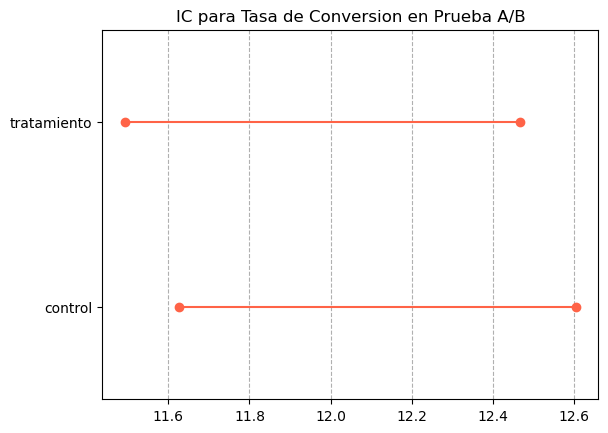

In [26]:
#Visualizar los intervalos de confianza
data_dict = {}
data_dict['group'] = ['control','tratamiento']
data_dict['lower'] = [control_inf*100,treat_inf*100]
data_dict['upper'] = [control_sup*100,treat_sup*100]
intervalo = pd.DataFrame(data_dict)

for lower,upper,y in zip(intervalo['lower'],intervalo['upper'],range(len(intervalo))):
    plt.plot((lower,upper),(y,y),'o-',color="tomato")

plt.grid(axis="x",linestyle="--")
plt.ylim([-0.5,1.5])
plt.yticks(range(len(intervalo)),list(intervalo['group']))
plt.title("IC para Tasa de Conversion en Prueba A/B")

plt.show()

## Analisis granular

In [31]:
#Extraer tasas de conversion del grupo de control
control_conv_dia = ab_test.query("group == 'control'").groupby("day").agg(
    casos = ("converted","count"),
    conv = ("converted","sum")
)
control_conv_dia["casos_acum"] = control_conv_dia["casos"].cumsum()
control_conv_dia["conv_acum"] = control_conv_dia["conv"].cumsum()
control_conv_dia["conv_rate_c"] = control_conv_dia["conv_acum"]/control_conv_dia["casos_acum"]*100
control_conv_dia.drop(columns=["casos","conv","casos_acum","conv_acum"],inplace=True)

In [34]:
#Extraer tasas de conversion del grupo de tratamiento
treat_conv_dia = ab_test.query("group == 'treatment'").groupby("day").agg(
    casos = ("converted","count"),
    conv = ("converted","sum")
)
treat_conv_dia["casos_acum"] = treat_conv_dia["casos"].cumsum()
treat_conv_dia["conv_acum"] = treat_conv_dia["conv"].cumsum()
treat_conv_dia["conv_rate_t"] = treat_conv_dia["conv_acum"]/treat_conv_dia["casos_acum"]*100
treat_conv_dia.drop(columns=["casos","conv","casos_acum","conv_acum"],inplace=True)

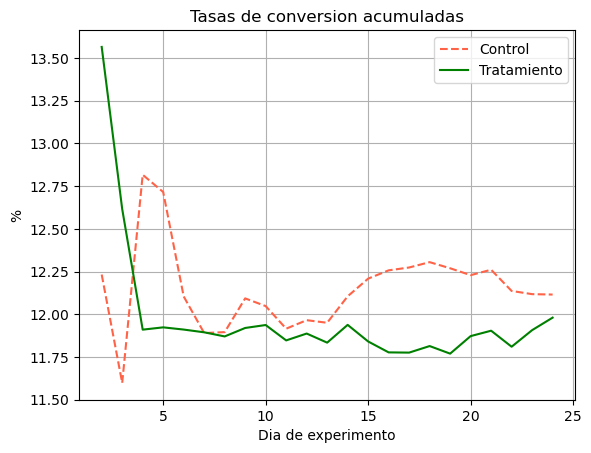

In [35]:
#Tabla consolidada
conv_dia = control_conv_dia.merge(
    treat_conv_dia,
    on = "day"
)

#Visualizar tablas de conversion acumuladas
conv_dia.plot(
    kind = "line",
    title = "Tasas de conversion acumuladas",
    xlabel = "Dia de experimento",
    ylabel = "%",
    style=["--","-"],
    color=["tomato","green"],
    grid=True
)

plt.legend(["Control","Tratamiento"])
plt.show()


In [37]:
#Calcular el IC para las diferencias de la tasa de conversión
error = np.sqrt((1+conversion_rates.loc['control','st_error'])**2 * (1+conversion_rates.loc['treatment','st_error'])**2)-1

IC = [100*(0-z_stat*error),100*(0+z_stat*error)]
IC

[-0.19126306054410966, 0.19126306054410966]

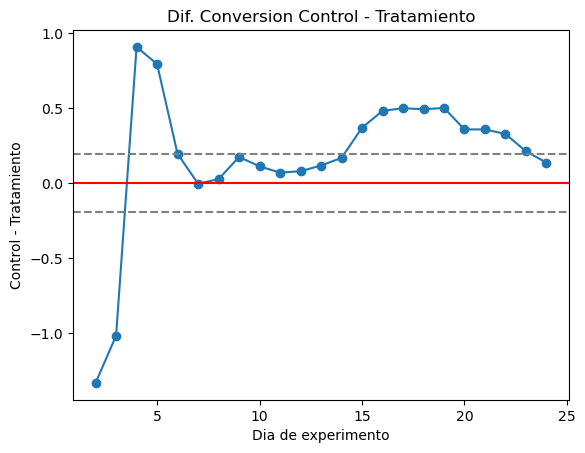

In [38]:
#Visualizar la diferencia entre las tasas de conversion
conv_dia["dif"] = conv_dia["conv_rate_c"] - conv_dia["conv_rate_t"]

conv_dia.plot(
    y = "dif",
    kind = "line",
    marker="o",
    title = "Dif. Conversion Control - Tratamiento",
    xlabel = "Dia de experimento",
    ylabel = "Control - Tratamiento",
    legend=None
)

plt.axhline(0,color = "red")
plt.axhline(IC[0],color = "gray",linestyle="--")
plt.axhline(IC[1],color = "gray",linestyle="--")
plt.show()